# 6. Domainloop stats

Part of the **[Fig. 4 chapter](fig4.md)** — see it for the panel-by-panel map. The first code cell sets `ENTEX_ROOT` and activates the no-overwrite guard (see the [Reproduction guide](../reproduce.md)). *Outputs shown are the author's original run.*


In [ ]:
# === Reproduction setup — edit ENTEX_ROOT / REF_ROOT for your machine ===
import os, sys
ENTEX_ROOT = os.environ.get('ENTEX_ROOT', '/large_storage/zhoulab/zhoujt/project/ENTEx')
REF_ROOT   = os.environ.get('REF_ROOT',   '/large_storage/zhoulab/ref')
BOOK_ROOT  = os.environ.get('BOOK_ROOT',  f'{ENTEX_ROOT}/analysis/HumanCellEpigenomeAtlas')
sys.path.insert(0, BOOK_ROOT)
os.chdir(f'{ENTEX_ROOT}/analysis')   # original working directory
import repro_guard                    # no-overwrite guard (default: skip existing)

In [1]:
import numpy as np
import pandas as pd
from glob import glob
from scipy.sparse import csr_matrix
from scipy.stats import zscore
from concurrent.futures import ProcessPoolExecutor, as_completed

import anndata

import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Helvetica'

import warnings
warnings.filterwarnings("ignore")


In [2]:
indir = f'{ENTEX_ROOT}/'


In [3]:
L1_meta = pd.read_csv(f'{indir}L1color.tsv', sep='\t', header=0, index_col=0)
L1_meta = L1_meta.drop(['c35', 'c36'], axis=0)
L1_annot = L1_meta['L1_abbr'].to_dict()
L1_color = L1_meta['color'].to_dict()


In [ ]:
!hicluster domain --cell_table_path coollist_L1_impute25k.tsv --output_prefix L1_impute --resolution 25000 --cpu 20


In [26]:
adata_raw = anndata.read_h5ad(f'{indir}analysis/domain/L1_raw.boundary.h5ad')
adata_impute = anndata.read_h5ad(f'{indir}analysis/domain/L1_impute.boundary.h5ad')[adata_raw.obs.index]


In [31]:
tad_stats = []
tad_all_raw = []
tad_all_impute = []
for i,ct in enumerate(adata_raw.obs.index):
    tmp1 = np.repeat(adata_raw.X[i].indices, adata_raw.X[i].data).reshape((-1, 2))
    tmp2 = np.repeat(adata_impute.X[i].indices, adata_impute.X[i].data).reshape((-1, 2))
    tad_stats.append([tmp1.shape[0], (tmp1[:,1]-tmp1[:,0]).mean(), tmp2.shape[0], (tmp2[:,1]-tmp2[:,0]).mean()])
    tmp1 = pd.DataFrame(tmp1)
    tmp1['L1'] = ct
    tmp1['length'] = (tmp1[1] - tmp1[0]) * 25000
    tmp2 = pd.DataFrame(tmp2)
    tmp2['L1'] = ct
    tmp2['length'] = (tmp2[1] - tmp2[0]) * 25000
    tad_all_raw.append(tmp1[['L1', 'length']])
    tad_all_impute.append(tmp2[['L1', 'length']])
    
tad_stats = pd.DataFrame(tad_stats, index=adata_raw.obs.index, 
                         columns=['raw_count', 'raw_length', 'impute_count', 'impute_length'])
tad_stats[['raw_length', 'impute_length']] *= 25000
tad_stats = tad_stats.loc[L1_meta.index]
tad_all_raw = pd.concat(tad_all_raw, axis=0)
tad_all_impute = pd.concat(tad_all_impute, axis=0)


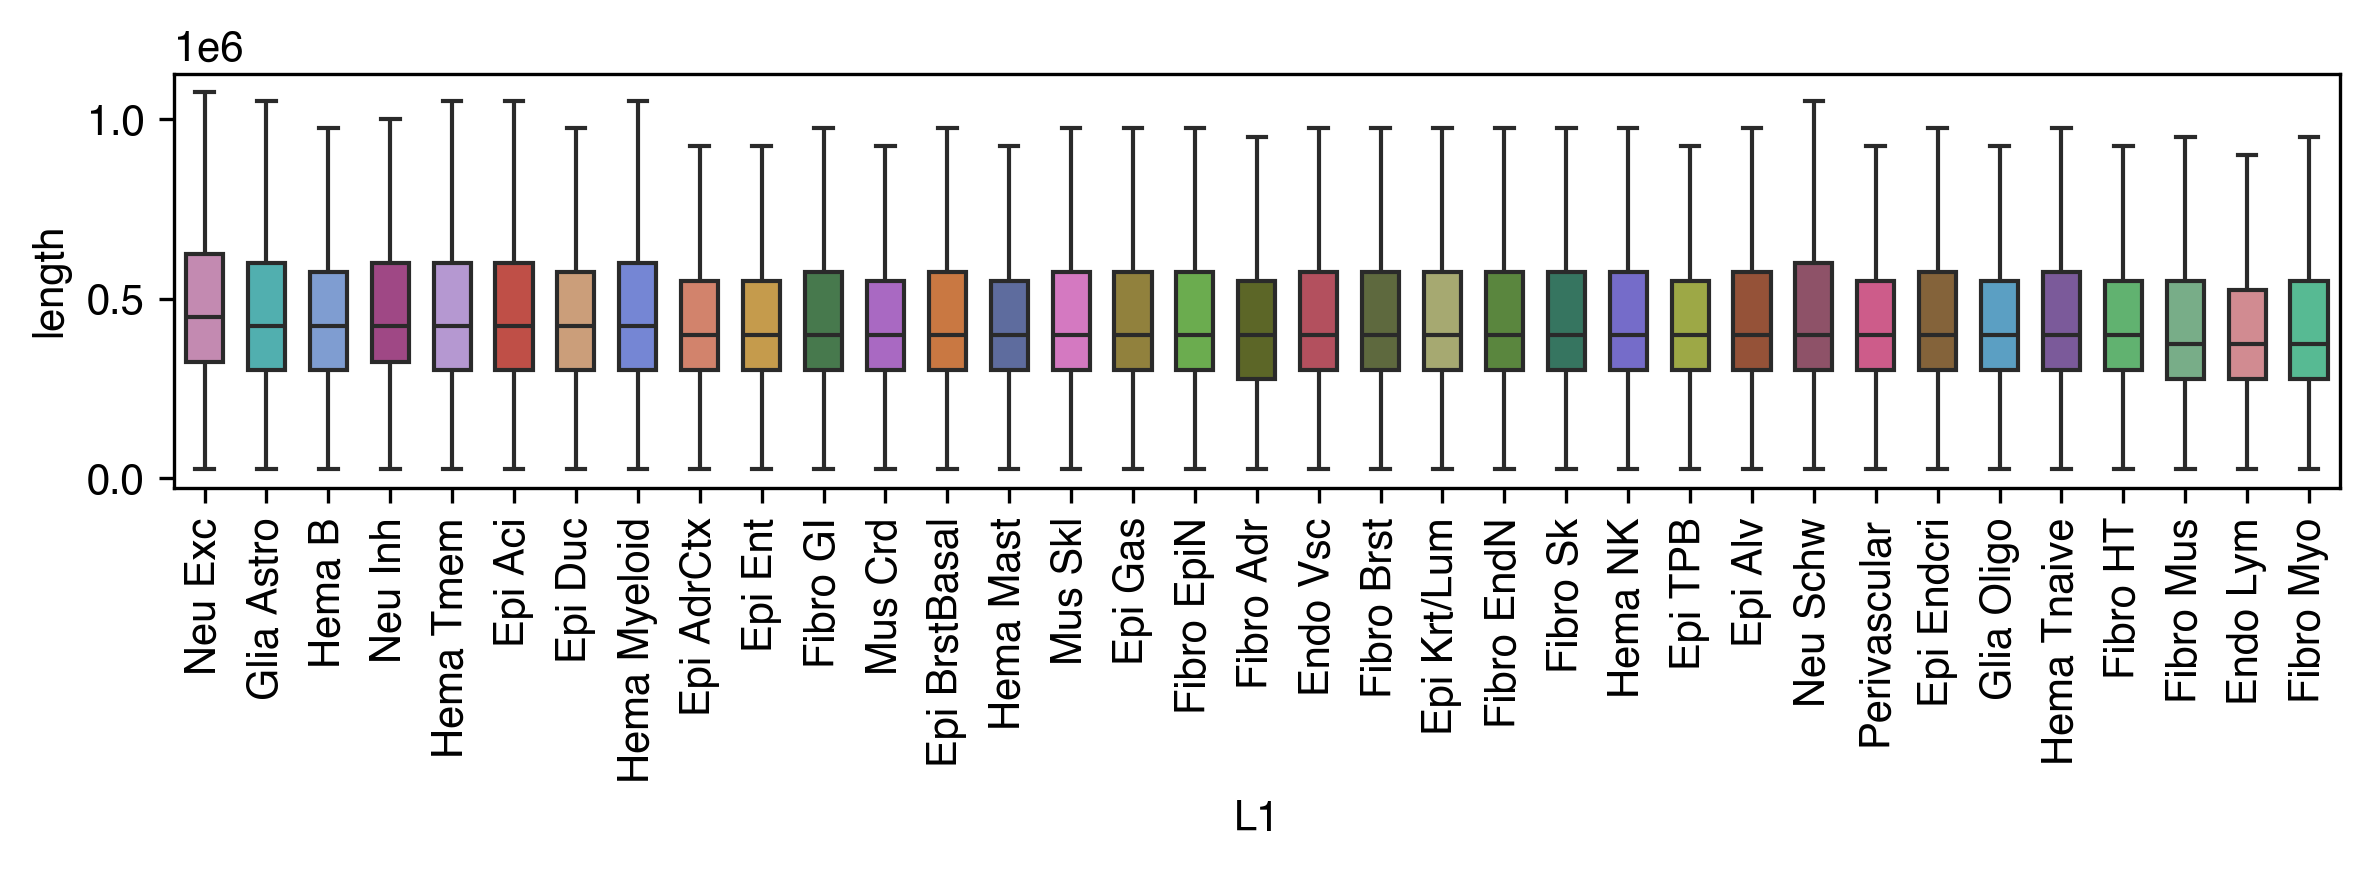

In [32]:
leg_order = tad_all_raw.groupby('L1')['length'].median().sort_values().index[::-1]
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
# sns.violinplot(loop_all, x='L1', y='length', order=leg_order, inner=None,
#                palette=L1_meta['color'].to_dict(), ax=ax)
sns.boxplot(tad_all_raw, x='L1', y='length', order=leg_order, width=0.6, ax=ax, 
            showfliers=False, palette=L1_meta['color'].to_dict(), 
            # showcaps=False, boxprops={'facecolor': 'None'}, 
            # medianprops={'color': 'w', 'linewidth': 1}
           )
ax.set_xticklabels(leg_order.map(L1_meta['L1_abbr']), rotation=90)
fig.tight_layout()
fig.savefig(f'domain/domain_raw_length_box.pdf', transparent=True)


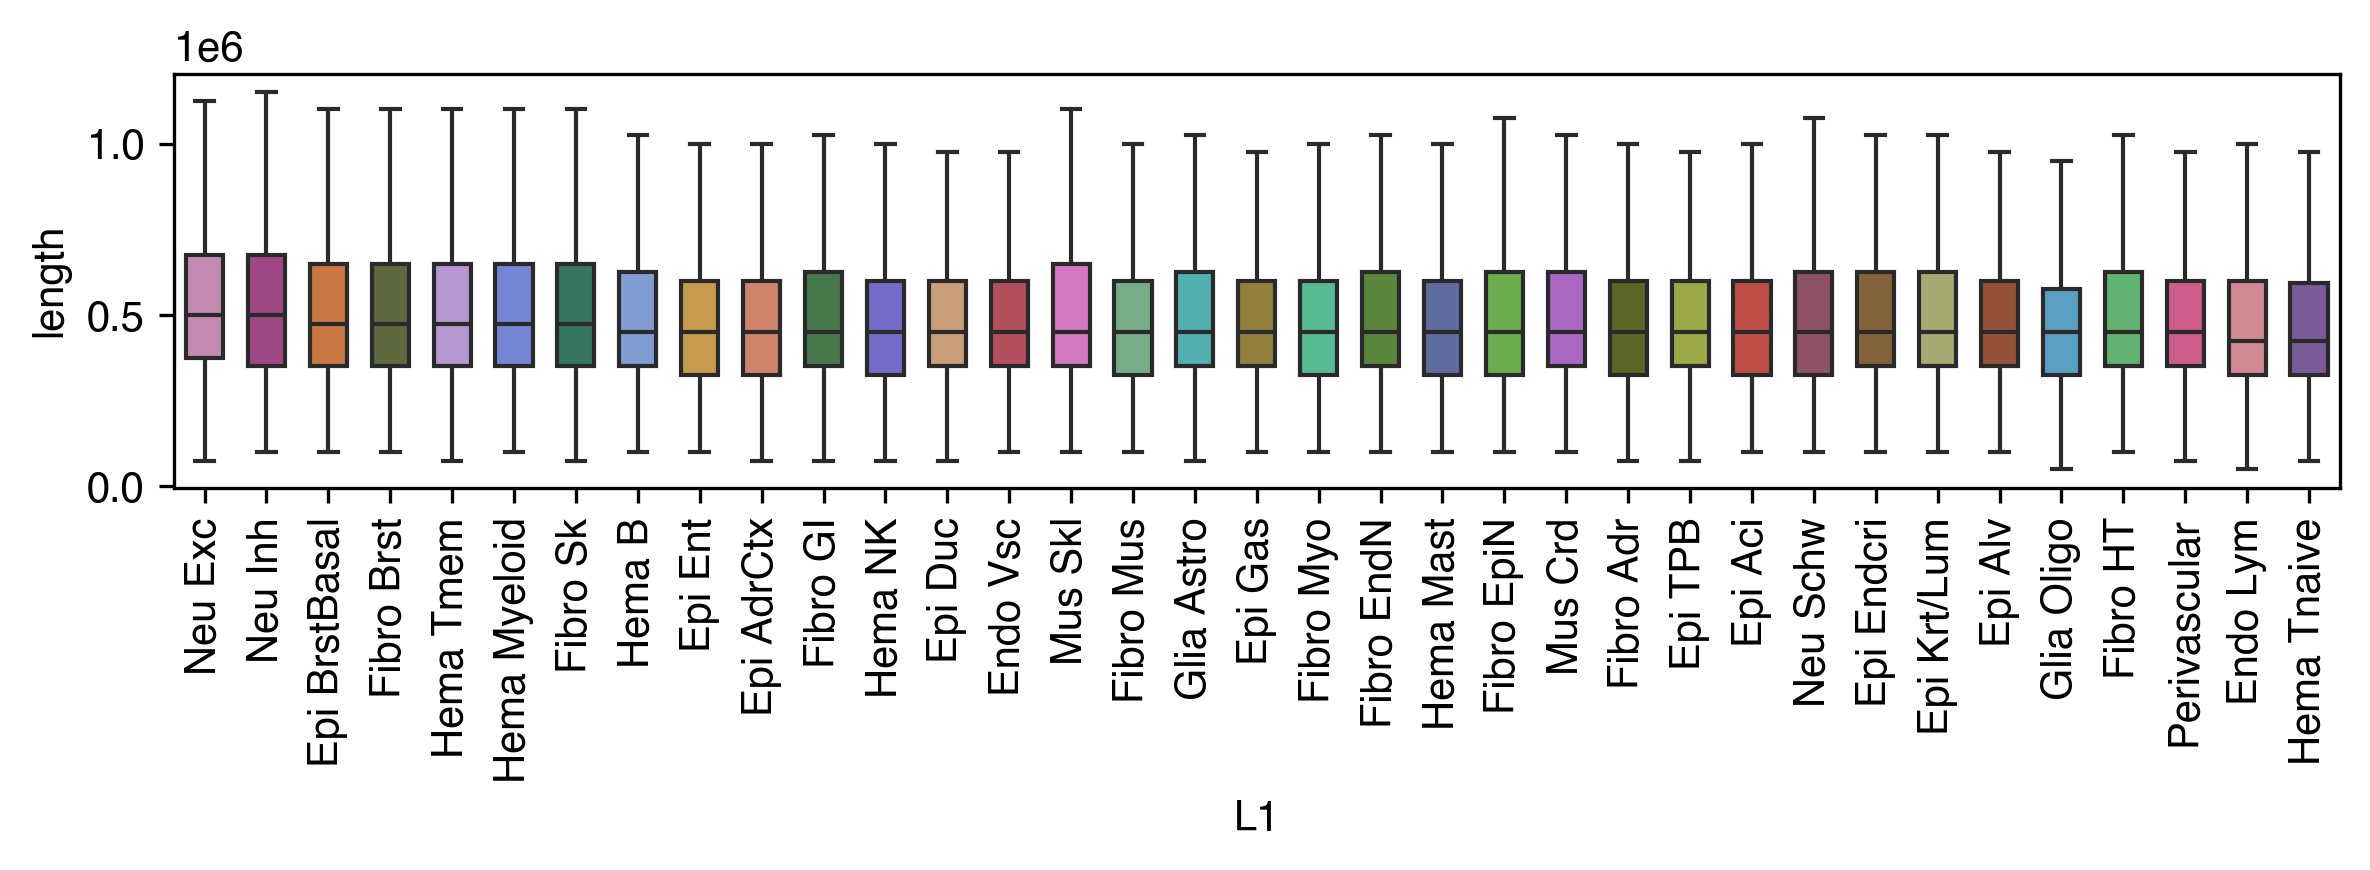

In [54]:
leg_order = tad_all_impute.groupby('L1')['length'].median().sort_values().index[::-1]
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
# sns.violinplot(loop_all, x='L1', y='length', order=leg_order, inner=None,
#                palette=L1_meta['color'].to_dict(), ax=ax)
sns.boxplot(tad_all_impute, x='L1', y='length', order=leg_order, width=0.6, ax=ax, 
            showfliers=False, palette=L1_meta['color'].to_dict(), 
            # showcaps=False, boxprops={'facecolor': 'None'}, 
            # medianprops={'color': 'w', 'linewidth': 1}
           )
ax.set_xticklabels(leg_order.map(L1_meta['L1_abbr']), rotation=90)
fig.tight_layout()
fig.savefig(f'domain/domain_impute_length_box.pdf', transparent=True)


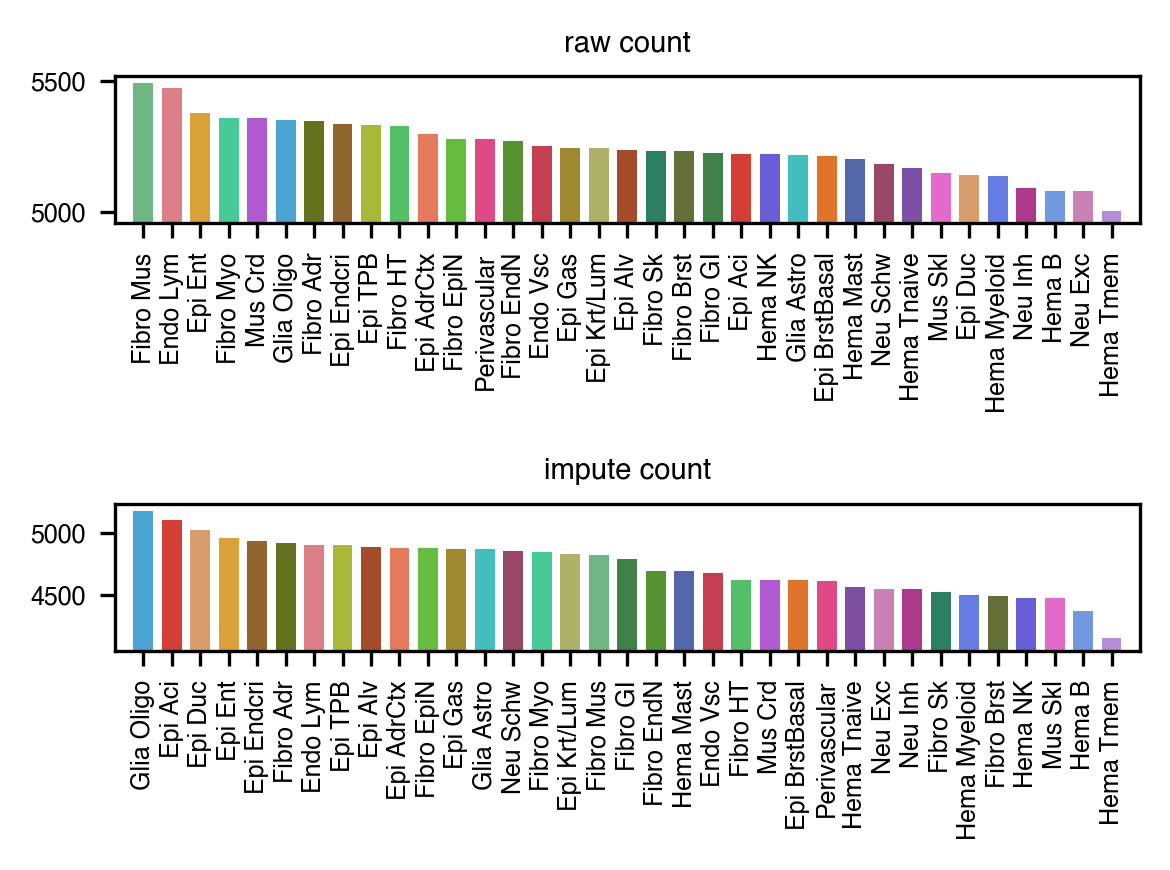

In [47]:
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300)
# ax.spines['bottom'].set_position('zero')
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
xticks = np.arange(tad_stats.shape[0])
for i,xx in enumerate(['raw_count', 'impute_count']):
    ax = axes[i]
    leg_order = tad_stats.sort_values(xx).index[::-1]
    tmp = tad_stats.loc[leg_order]
    # bottom = [1e3, 1e3][i]
    bottom = tmp[xx].min()
    height = tmp[xx] - bottom
    bottom -= height.max() * 0.1
    height += height.max() * 0.1
    # if bottom>0:
    bottom = np.ones(tmp.shape[0]) * bottom
    # else:
    #     bottom = np.zeros(tmp.shape[0])
    #     height = tmp[xx]
    ax.bar(x=np.arange(tad_stats.shape[0]), height=height, bottom=bottom, 
           color=tmp.index.map(L1_color), width=0.7)
    ax.set_xticks(xticks)
    ax.set_xticklabels(tmp.index.map(L1_annot), fontsize=6, rotation=90)
    # ax.set_yscale('log')
    ax.set_xlim([-1, tad_stats.shape[0]])
    # ax.set_yscale('log')
    # ax.set_yticks([[1e4, 1e5, 1e6], [1e3, 1e4, 1e5]][i])
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    ax.set_title(xx.replace('_', ' '), fontsize=7)
    
fig.tight_layout()
fig.savefig(f'domain/domain_length_bar.pdf', transparent=True)


In [61]:
import cooler
cool = cooler.Cooler(f'{ENTEX_ROOT}/merged_cool_impute/25K/L1/c7-b1.Q.cool')


In [62]:
cool.info['group_n_cells']

3

In [4]:
loop_stats = []
loop_all = []
summit_all = []
for ct in L1_meta.index:
    tmp = pd.read_csv(f'{indir}loop/majortype/{ct}/{ct}.loop.bedpe', sep='\t', header=None, index_col=None)
    tmp2 = pd.read_csv(f'{indir}loop/majortype/{ct}/{ct}.loop_summit.bedpe', sep='\t', header=None, index_col=None)
    loop_stats.append([tmp.shape[0], (tmp[4]-tmp[1]).mean(), tmp2.shape[0], (tmp2[4]-tmp2[1]).mean()])
    tmp['L1'] = ct
    tmp['length'] = tmp[4] - tmp[1]
    tmp2['L1'] = ct
    tmp2['length'] = tmp2[4] - tmp2[1]
    loop_all.append(tmp[['L1', 'length']])
    summit_all.append(tmp2[['L1', 'length']])
        
loop_stats = pd.DataFrame(loop_stats, columns=['pixel_count', 'pixel_length', 'summit_count', 'summit_length'], index=L1_meta.index)
loop_all = pd.concat(loop_all, axis=0)
summit_all = pd.concat(summit_all, axis=0)


In [8]:
print(loop_all.shape[0], summit_all.shape[0])

11180225 724461


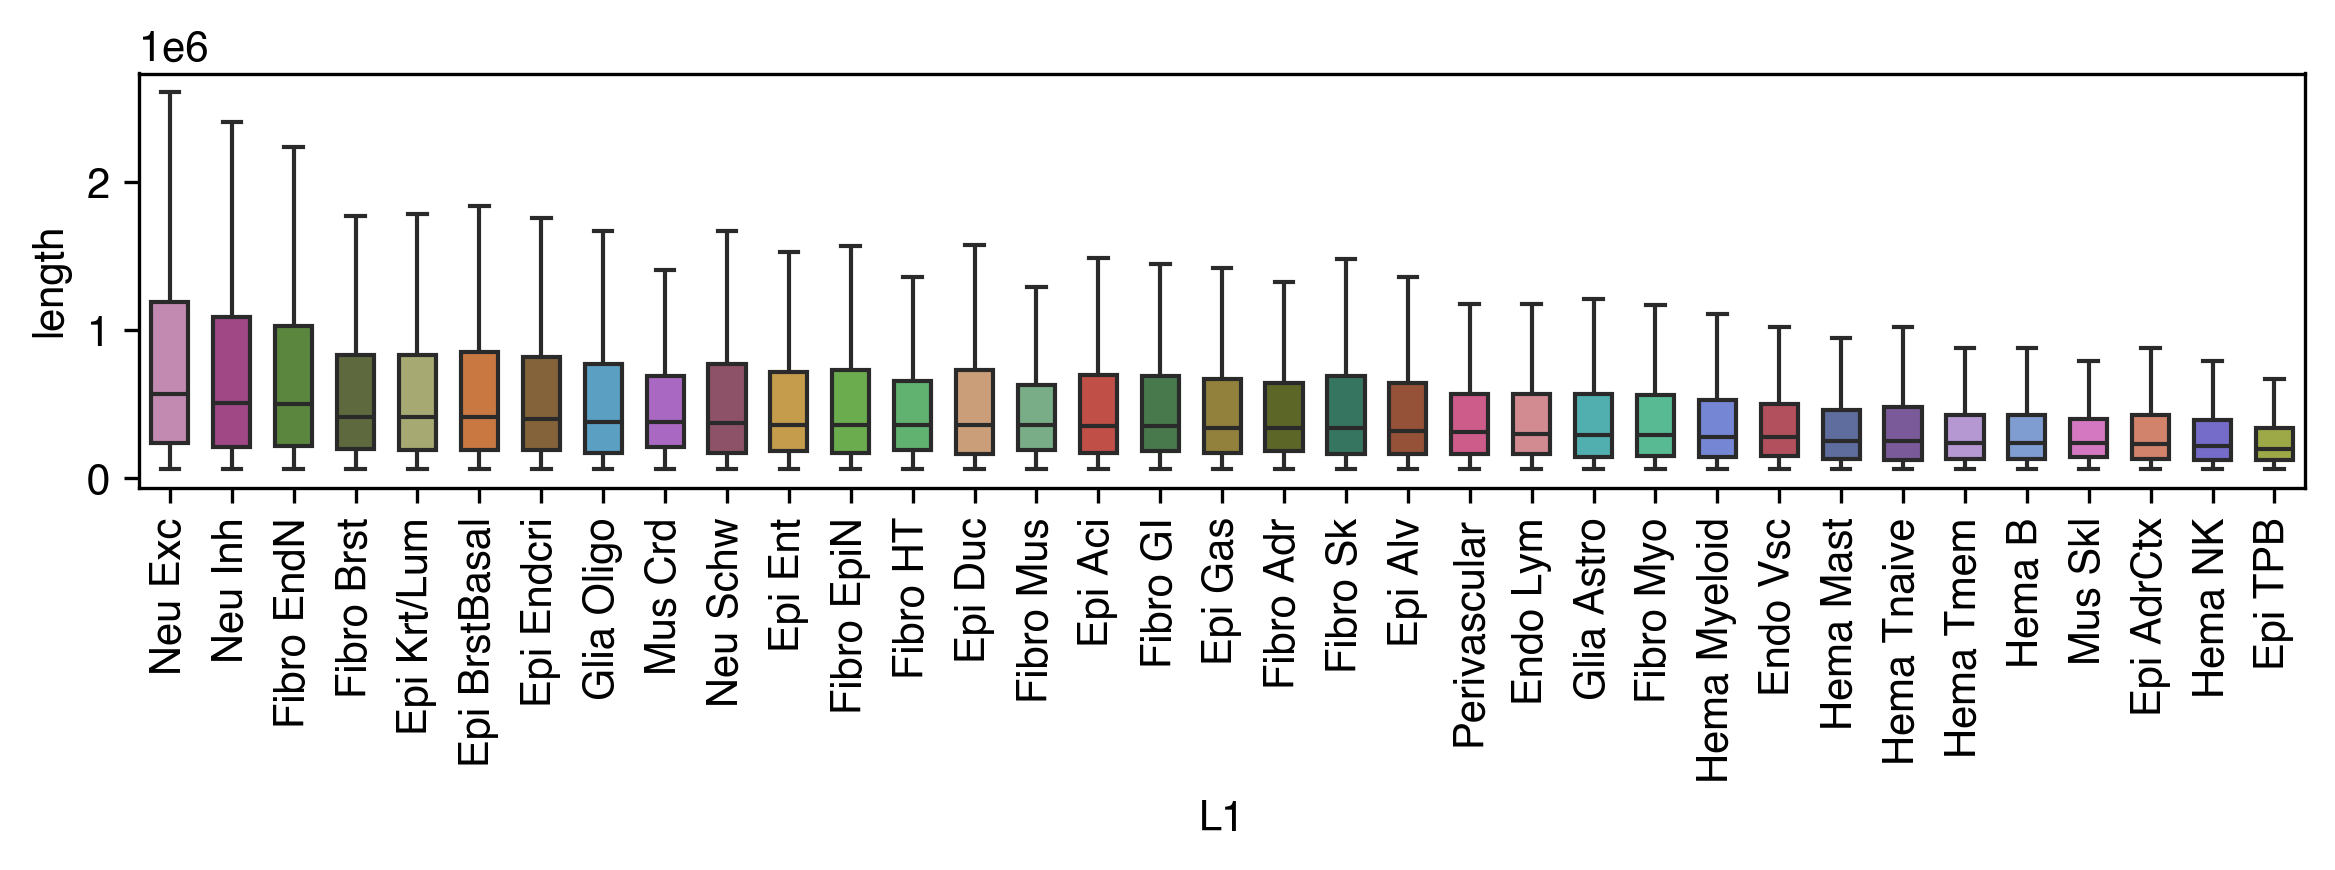

In [15]:
leg_order = loop_all.groupby('L1')['length'].median().sort_values().index[::-1]
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
# sns.violinplot(loop_all, x='L1', y='length', order=leg_order, inner=None,
#                palette=L1_meta['color'].to_dict(), ax=ax)
sns.boxplot(loop_all, x='L1', y='length', order=leg_order, width=0.6, ax=ax, 
            showfliers=False, palette=L1_meta['color'].to_dict(), 
            # showcaps=False, boxprops={'facecolor': 'None'}, 
            # medianprops={'color': 'w', 'linewidth': 1}
           )
ax.set_xticklabels(leg_order.map(L1_meta['L1_abbr']), rotation=90)
fig.tight_layout()
fig.savefig(f'diff_loop/loop_length_box.pdf', transparent=True)


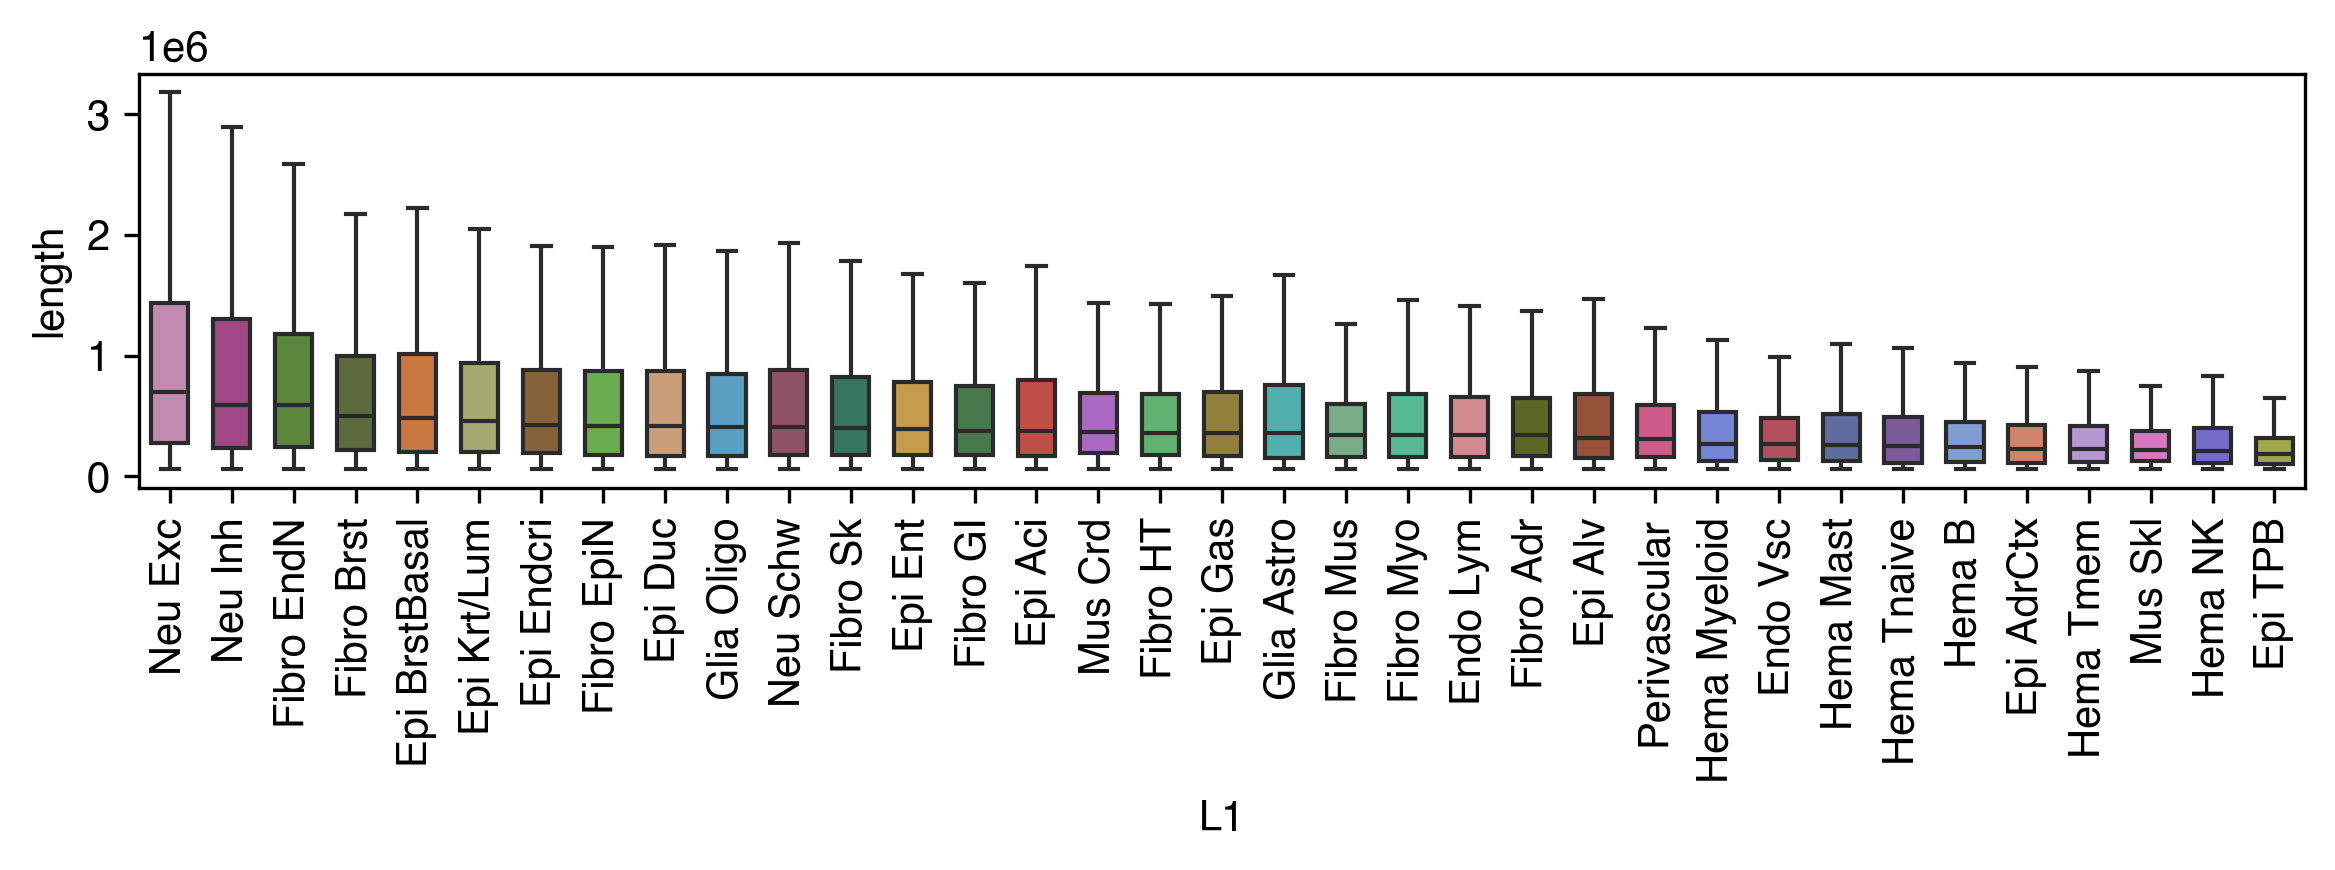

In [7]:
leg_order = summit_all.groupby('L1')['length'].median().sort_values().index[::-1]
fig, ax = plt.subplots(figsize=(8,3), dpi=300)
# sns.violinplot(loop_all, x='L1', y='length', order=leg_order, inner=None,
#                palette=L1_meta['color'].to_dict(), ax=ax)
sns.boxplot(summit_all, x='L1', y='length', order=leg_order, width=0.6, ax=ax, 
            showfliers=False, palette=L1_meta['color'].to_dict(), 
            # showcaps=False, boxprops={'facecolor': 'None'}, 
            # medianprops={'color': 'w', 'linewidth': 1}
           )
ax.set_xticklabels(leg_order.map(L1_meta['L1_abbr']), rotation=90)
fig.tight_layout()
fig.savefig(f'diff_loop/loop_summit_length_box.pdf', transparent=True)


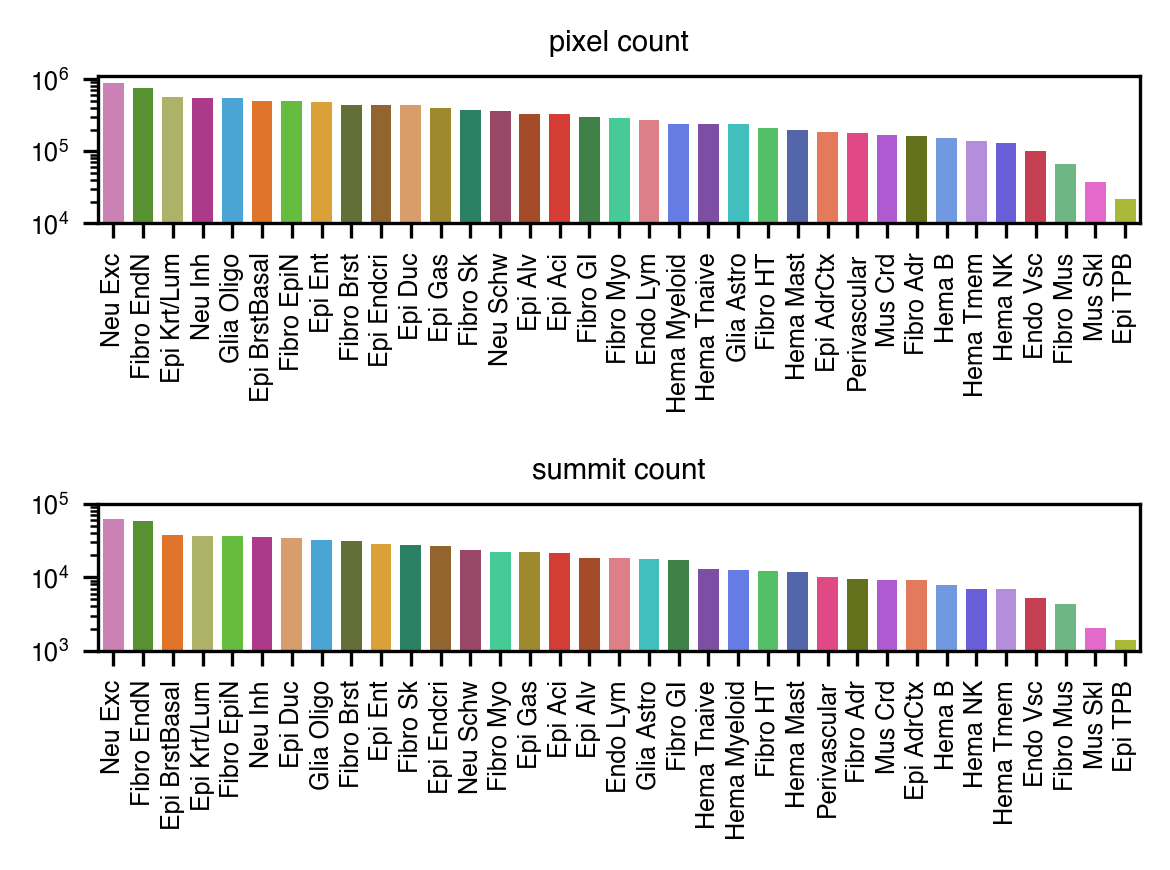

In [46]:
fig, axes = plt.subplots(2, 1, figsize=(4, 3), dpi=300)
# ax.spines['bottom'].set_position('zero')
# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
xticks = np.arange(loop_stats.shape[0])
for i,xx in enumerate(['pixel_count', 'summit_count']):
    ax = axes[i]
    leg_order = loop_stats.sort_values(xx).index[::-1]
    tmp = loop_stats.loc[leg_order]
    bottom = [1e4, 1e3][i]
    # bottom = tmp[xx].min()
    height = tmp[xx] - bottom
    # bottom -= height.max() * 0.1
    # height += height.max() * 0.1
    # if bottom>0:
    bottom = np.ones(tmp.shape[0]) * bottom
    # else:
    #     bottom = np.zeros(tmp.shape[0])
    #     height = tmp[xx]
    ax.bar(x=np.arange(loop_stats.shape[0]), height=height, bottom=bottom, 
           color=tmp.index.map(L1_color), width=0.7)
    ax.set_xticks(xticks)
    ax.set_xticklabels(tmp.index.map(L1_annot), fontsize=6, rotation=90)
    # ax.set_yscale('log')
    ax.set_xlim([-0.5, loop_stats.shape[0]-0.5])
    ax.set_yscale('log')
    ax.set_yticks([[1e4, 1e5, 1e6], [1e3, 1e4, 1e5]][i])
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6)
    ax.set_title(xx.replace('_', ' '), fontsize=7)
    
fig.tight_layout()
fig.savefig(f'diff_loop/loop_stats_bar.pdf', transparent=True)


In [9]:
from schicluster.loop.loop_calling import find_summit
bedpe_cols = ['chrom', 'x1', 'x2', 'chrom2', 'y1', 'y2', 'E']
loop = pd.read_csv(f'{indir}loop/majortype/c1/c1.loop.bedpe', header=None, index_col=None, sep='\t')
loop.columns = bedpe_cols.copy()


In [10]:
dist_thres, resolution = 20000, 10000
summit = pd.concat([
            find_summit(
                loop=sub_df, res=resolution, dist_thres=dist_thres // resolution)
            for chrom, sub_df in loop.groupby('chrom')
        ],
            axis=0)

In [17]:
(summit['size']>1).sum()

6546

In [4]:
looppath = pd.read_csv(f'{indir}loop/subtype/subtype-loop-path.csv', header=0, index_col=0)


In [9]:
looppath

,celltype_L2_both-tissue,celltype_L2_both,loop_path
52,c3-b11-P,c3-b11,gs://ecker-may-entex-analysis/loop/122024-subt...
56,c3-b12-AG,c3-b12,gs://ecker-may-entex-analysis/loop/122024-subt...
63,c3-b14-LV,c3-b14,gs://ecker-may-entex-analysis/loop/122024-subt...
64,c3-b13-M1C,c3-b13,gs://ecker-may-entex-analysis/loop/241218-subt...
114,c22-b0-PI,c22-b0,gs://ecker-may-entex-analysis/loop/241218-subt...
...,...,...,...
1117,c16-b11-M1C,c16-b11,gs://ecker-may-entex-analysis/loop/241218-subt...
1118,c16-b12-M1C,c16-b12,gs://ecker-may-entex-analysis/loop/241218-subt...
1120,c16-b13-M1C,c16-b13,gs://ecker-may-entex-analysis/loop/241218-subt...
1124,c21-b5-NTb,c21-b5,gs://ecker-may-entex-analysis/loop/241218-subt...


In [11]:
import os
from concurrent.futures import ProcessPoolExecutor, as_completed

def download(group, ct, path):
    cmd = f'gsutil cp {path}/{group}/{group}.loop.bedpe {indir}loop/subtype/{ct}.loop.bedpe'
    os.system(cmd)
    return ct
    
def check(group, ct, path):
    cmd = f'gsutil ls {path}/Success > success_{ct}.txt'
    os.system(cmd)
    return ct
    
cpu = 30
with ProcessPoolExecutor(cpu) as executor:
    futures = {}
    for group,ct,path in looppath.values:
        future = executor.submit(
            check,
            group=group,
            ct=ct,
            path=path,
        )
        futures[future] = ct

    result = {}
    for future in as_completed(futures):
        ct = futures[future]
        result[ct] = future.result()
        print(f'{ct} finished')
    

CommandException: One or more URLs matched no objects.


c20-b0 finished
c6-b11 finished
c6-b12 finished


CommandException: One or more URLs matched no objects.


c32-b1 finished
c34-b2 finished


CommandException: One or more URLs matched no objects.


...

c9-b1 finished
c17-b1 finished
c18-b5 finished
c8-b1 finished
c20-b3 finished
c4-b4 finished
c29-b0 finished


CommandException: One or more URLs matched no objects.
CommandException: One or more URLs matched no objects.


c2-b1 finished
c30-b0 finished
c29-b4 finished


CommandException: One or more URLs matched no objects.
CommandException: One or more URLs matched no objects.


c3-b11 finished
c3-b14 finished
c4-b3 finished
c4-b2 finished


In [ ]:
for f in $(cat success*txt | awk -F'/' '{print $(NF-1)}' | cut -d- -f1-2 | sort); do wc -l ${f}.loop.bedpe; done
